In [ ]:
import pandas as pd
import re, os, json
from tqdm.notebook import tqdm

In [ ]:
df = pd.read_excel('FAERS-BERT-TEST.xlsx')
df.shape

In [ ]:
# VAERS analyses
df = pd.read_excel('FAERS-BERT-WHOLE.xlsx')
df.shape

In [ ]:
df.tail(5)

In [ ]:
import spacy
from spacy.tokens import DocBin

train_file = '../new_results/data/processed_data/train_FAVERS_R1_v1_SME1_new_revision.spacy'
# train_file = '../new_results/data/rocessed_data/train_VAERS_SME1_revision.spacy.spacy'

def load_spacy_file(file_path):
    """Load a .spacy file and return a list of Doc objects"""
    nlp = spacy.blank("en")
    doc_bin = DocBin().from_disk(file_path)
    return list(doc_bin.get_docs(nlp.vocab))

data_train = load_spacy_file(train_file)

In [ ]:
data_train_unique = set([x.text.lower().strip() for x in data_train])

In [ ]:
res=[]
folder = '../Datasets/VAERS'
#folder = '../Datasets/FAERS_D1_clean'
for file in tqdm(os.listdir(folder)):
    if file.endswith('.json'):
        tmp_data = json.load(open(folder+'/'+file, 'r'))
        text = tmp_data['pages'][0].lower()
        count = 0
        total_char = 0
        for sent in data_train_unique:
            if sent in text:
                count +=1
                total_char += len(sent)
        mapped_ratio = total_char / len(text) * 100
        res.append([file, count, total_char, len(text), mapped_ratio])

In [ ]:
train_file = pd.DataFrame(res, columns = ['File', 'Sent_Match', 'Match_Char', 'Total_Char', 'Mapped_Ratio(%)'])

In [ ]:
train_file

In [ ]:
test_file_list = []
for ind, d in train_file.iterrows():
    if d['Mapped_Ratio(%)'] < 4:
        test_file_list.append(d['File'])
print(len(test_file_list))

In [ ]:
# Finalize the testing dataset by only considering the 136 testing files
# 
df_test = df[df['File'].isin(test_file_list)]
df_test.shape

In [ ]:
# Label Normalizer to FAERS R4
Label_pool = {'AE': 'AE',
             'TEMPO': 'TEMPO',
             'SDRUG': 'DRUG',
             'DRUG': 'DRUG',
             'STATUS': 'STATUS',
             'CDRUG': 'DRUG',
             'BSYM': 'DX',
             'DOSE': 'DOSE',
             'LAB': 'LAB',
             'HX': 'MHX',
             'TREATMENT': 'DX',
             'SEX': 'SEX',
             'AGE': 'AGE',
             'MHX': 'MHX',
             'DX': 'DX',
             'DIAGNOSIS': 'DX',
             'MAE': 'AE',
             'FHX': 'FHX',
             'COD': 'AE',
             'BYSM': 'MHX',
             'DIAGNOSES': 'DX',
             
             'DATE':'TEMPO',
             'IND':'INDICATION',
             'ODRUG':'DRUG',
             'DURATION': 'TEMPO',
             'TIME': 'TEMPO',
             'TEMPORAL': 'TEMPO',
             'RELATIVE': 'TEMPO',
             'LATENCY': 'TEMPO',   
             'FREQUENCY': 'TEMPO',
             'BASELINE SYMPTOM': 'MHX',
             'CAUSE OF DEATH': 'COD',
             'MEDICAL HISTORY':'MHX',
             'FAMILY HISTORY':'FHX',
             'R/O':'RO',
             'RO':'RO',
             }

df_test['Label_Norm'] = [Label_pool.get(d['Label'].upper(),'Others') for _, d in df_test.iterrows()]

In [ ]:
df_test['Label'].unique()

In [ ]:
# Label Normalizer to FAERS R4
Label_pool = {'VAX':'VAX',
               'Tx':'TX', 
               'pDx':'DX',
               'Status':'STATUS', 
               'SYM':'SYM', 
               'sDx':'DX', 
               'Lab':'LAB', 
               'TEMPO':'TEMPO', 
               'AGE':'AGE',
               'DX':'DX', 
               'TREATMENT':'TX', 
               'Dx':'DX', 
               'MHx':'HX', 
               'SEX':'SEX', 
               'STATUS':'STATUS', 
               'Hx':'HX', 
               'HX':'HX',
               'DOSE':'DOSE', 
               'TX':'TX', 
               'LAB':'LAB', 
               'R/O':'RO', 
               'FHx':'HX', 
               'RO':'RO', 
               'CoD':'OTHER', 
               'LAB=INFLAMMATION':'LAB',
               'DX{LUMBOSACRAL':'DX', 
               'DX"INFLAMMATORY':'DX'
             }

df_test['Label_Norm'] = [Label_pool.get(d['Label'],'Others') for _, d in df_test.iterrows()]

In [ ]:
df_test.to_excel('VAERS-BERT-TEST.xlsx',index=None)

## Final Analyses - Test Dataset is ready 

In [7]:
import pandas as pd

def spans_overlap(a_start, a_end, b_start, b_end):
    """
    Returns True if two spans overlap at all.
    Treat spans as [start, end) intervals.
    """
    return (a_start < b_end) and (b_start < a_end)


def compute_counts_for_system(tmp_df: pd.DataFrame, system_note: str):
    """
    Compute M, C, S, N for a given system (e.g., 'BERT' or 'LLM')
    compared to Human annotations, per Label_Norm and overall TOTAL.
    """
    df = tmp_df[tmp_df['Note'].isin(['Human', system_note])].copy()

    label_list = sorted(df['Label_Norm'].unique())
    counts = {label: {'M': 0, 'C': 0, 'S': 0, 'N': 0} for label in label_list}
    counts['TOTAL'] = {'M': 0, 'C': 0, 'S': 0, 'N': 0}

    for file_id in df['File'].unique():
        file_df = df[df['File'] == file_id]

        for label in label_list:
            sub = file_df[file_df['Label_Norm'] == label]

            human_spans_df = sub[sub['Note'] == 'Human'][['Start', 'End']].drop_duplicates()
            sys_spans_df   = sub[sub['Note'] == system_note][['Start', 'End']].drop_duplicates()

            human_spans = [
                {'start': int(row.Start), 'end': int(row.End), 'matched': False}
                for row in human_spans_df.itertuples(index=False)
            ]
            sys_spans = [
                {'start': int(row.Start), 'end': int(row.End), 'matched': False}
                for row in sys_spans_df.itertuples(index=False)
            ]

            # 1) Exact matches (M)
            for h in human_spans:
                for s in sys_spans:
                    if (not h['matched'] and not s['matched'] and
                        h['start'] == s['start'] and h['end'] == s['end']):
                        h['matched'] = True
                        s['matched'] = True
                        counts[label]['M'] += 1
                        break  # move to next human span

            # 2) Partial matches (C) – overlapping but not exact and unused
            for h in human_spans:
                if h['matched']:
                    continue
                for s in sys_spans:
                    if s['matched']:
                        continue
                    if spans_overlap(h['start'], h['end'], s['start'], s['end']):
                        h['matched'] = True
                        s['matched'] = True
                        counts[label]['C'] += 1
                        break  # move to next human span

            # 3) False negatives (N): human spans not matched at all
            for h in human_spans:
                if not h['matched']:
                    counts[label]['N'] += 1

            # 4) False positives (S): system spans not matched at all
            for s in sys_spans:
                if not s['matched']:
                    counts[label]['S'] += 1

    # Fill TOTAL as sum across labels
    for label in label_list:
        for key in ['M', 'C', 'S', 'N']:
            counts['TOTAL'][key] += counts[label][key]

    return counts


def counts_to_metrics_df(counts: dict, model_name: str, methods='Weighted') -> pd.DataFrame:
    """
    Convert counts dict {label: {'M','C','S','N'}} to a DataFrame with
    M_, C_, S_, N_ and Precision / Recall / F1.
    """
    rows = []
    for label, c in counts.items():
        M = c['M']
        C = c['C']
        S = c['S']
        N = c['N']

        # Revised M', C', S', N' (using your formula)
        M_ = M + (0.5 * C)
        C_ = 0.5 * C
        S_ = 0.25 * S
        N_ = N
        if methods == 'Weighted':
            precision = M_ / (M_ + C_ + S_) if (M_ + C_ + S_) > 0 else 0.0
            recall    = M_ / (M_ + C_ + N_) if (M_ + C_ + N_) > 0 else 0.0
        else:
            precision = M / (M + C + S) if (M + C + S) > 0 else 0.0
            recall    = M / (M + C + N) if (M + C + N) > 0 else 0.0
        
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            'Model': model_name,
            'Label_Norm': label,
            'M': M,
            'C': C,
            'S': S,
            'N': N,
            'M_': M_,
            'C_': C_,
            'S_': S_,
            'N_': N_,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })

    # Order labels alphabetically, TOTAL at the bottom
    labels = sorted([lbl for lbl in counts.keys() if lbl != 'TOTAL']) + ['TOTAL']
    df = pd.DataFrame(rows)
    df['Label_Norm'] = pd.Categorical(df['Label_Norm'], categories=labels, ordered=True)
    df = df.sort_values(['Model', 'Label_Norm']).reset_index(drop=True)
    return df

In [12]:
df_test = pd.read_excel('VAERS-BERT-TEST.xlsx')

In [13]:
label_human = df_test[df_test['Note']=='Human']['Label_Norm'].unique()

In [15]:
label_human = label_human[:-1]
label_human

array(['VAX', 'TX', 'DX', 'STATUS', 'SYM', 'LAB', 'HX', 'RO'],
      dtype=object)

In [4]:
label_human = ['AGE', 'SEX', 'MHX', 'DRUG', 'AE', 'LAB', 'DX', 'DOSE', 'STATUS', ]

In [17]:
## remove these not annotated by human
df_test = df_test[df_test['Label_Norm'].isin(label_human)]

In [18]:
bert_counts = compute_counts_for_system(df_test, system_note='BERT')
llm_counts  = compute_counts_for_system(df_test, system_note='LLM')

bert_df = counts_to_metrics_df(bert_counts, model_name='BERT', methods='Unweighted')
llm_df  = counts_to_metrics_df(llm_counts,  model_name='LLM', methods='Unweighted')

results_df_total = pd.concat([bert_df, llm_df], ignore_index=True)

In [ ]:
for file in df_test['File']:
    tmp_df = df_test[df_test['File']==file].sort_values(['Start','End'],ascending=True)

    # ---- Run for BERT and LLM and combine ----
    bert_counts = compute_counts_for_system(tmp_df, system_note='BERT')
    llm_counts  = compute_counts_for_system(tmp_df, system_note='LLM')

    bert_df = counts_to_metrics_df(bert_counts, model_name='BERT')
    llm_df  = counts_to_metrics_df(llm_counts,  model_name='LLM')

    results_df = pd.concat([bert_df, llm_df], ignore_index=True)
    break

In [19]:
results_df_total.to_excel('VAERS_performance_uw.xlsx')

## Visualization

In [20]:
df_fig = pd.read_excel('VAERS_performance_uw.xlsx',index_col=0)
df_fig.head()

,Model,Label_Norm,M,C,S,N,M_,C_,S_,N_,Precision,Recall,F1
0,BERT,DX,878,247,754,380,1001.5,123.5,188.50,380,0.467270,0.583389,0.518913
1,BERT,HX,143,47,134,60,166.5,23.5,33.50,60,0.441358,0.572000,0.498258
2,BERT,LAB,294,145,245,228,366.5,72.5,61.25,228,0.429825,0.440780,0.435233
3,BERT,RO,6,13,19,41,12.5,6.5,4.75,41,0.157895,0.100000,0.122449
4,BERT,STATUS,185,32,107,86,201.0,16.0,26.75,86,0.570988,0.610561,0.590112


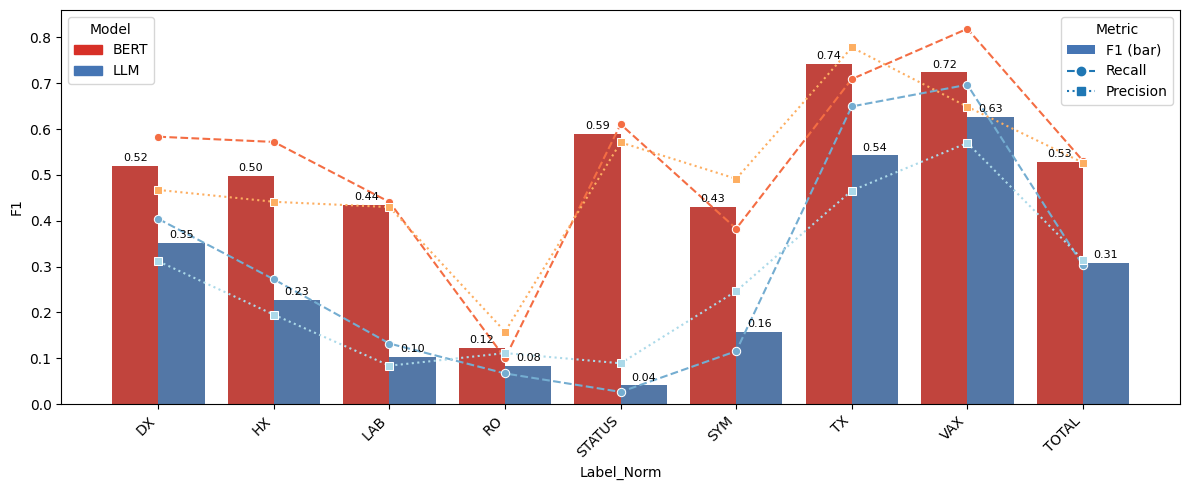

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))

# base colors per model
palette_f1 = {'BERT': '#d73027',  # dark red
              'LLM':  '#4575b4'}  # dark blue
palette_recall = {'BERT': '#f46d43',
                  'LLM':  '#74add1'}
palette_precision = {'BERT': '#fdae61',
                     'LLM':  '#abd9e9'}

# --- F1 as bars ---
bar_ax = sns.barplot(
    data=df_fig,
    x='Label_Norm',
    y='F1',
    hue='Model',
    palette=palette_f1,
    ax=ax
)

# add F1 value on top of each bar
for container in bar_ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",       # show F1 with 2 decimals
        label_type='edge',
        padding=2,
        fontsize=8
    )

# --- Recall as dashed lines with dots ---
sns.lineplot(
    data=df_fig,
    x='Label_Norm',
    y='Recall',
    hue='Model',
    palette=palette_recall,
    linestyle='--',
    marker='o',
    ax=ax,
    legend=False
)

# --- Precision as dotted lines with squares ---
sns.lineplot(
    data=df_fig,
    x='Label_Norm',
    y='Precision',
    hue='Model',
    palette=palette_precision,
    linestyle=':',
    marker='s',
    ax=ax,
    legend=False
)

# custom legends
model_handles = [
    mpatches.Patch(color=palette_f1['BERT'], label='BERT'),
    mpatches.Patch(color=palette_f1['LLM'], label='LLM')
]
legend_models = ax.legend(handles=model_handles, title='Model',
                          loc='upper left')

metric_handles = [
    mpatches.Patch(facecolor='#4575b4', label='F1 (bar)'),
    Line2D([0], [0], linestyle='--', marker='o', label='Recall'),
    Line2D([0], [0], linestyle=':', marker='s', label='Precision')
]
legend_metrics = ax.legend(handles=metric_handles, title='Metric',
                           loc='upper right')
ax.add_artist(legend_models)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Error analysis (FAERS)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Load
df = pd.read_excel("FAERS-BERT-TEST.xlsx")

# 2) Split by annotator / model
df_human = df[df["Note"] == "Human"].copy()
df_bert  = df[df["Note"] == "BERT"].copy()
df_llm   = df[df["Note"] == "LLM"].copy()


In [ ]:
from collections import defaultdict

def span_overlap(a_start, a_end, b_start, b_end):
    """Length of character overlap between two spans."""
    return max(0, min(a_end, b_end) - max(a_start, b_start))

def analyze_model(df_model, df_human):
    """
    Align model spans to human spans and classify errors using M/C/S/N:
      M = exact match (span + label)
      C = coverage error (boundary mismatch OR wrong label on overlapping span)
      S = spurious prediction (hallucination, no overlapping gold span)
      N = miss (gold span with no overlapping prediction)
    Also returns an entity-level confusion matrix (true vs predicted label),
    where counts are only incremented when labels differ (i.e., part of C).
    """
    human_by_file = {f: h for f, h in df_human.groupby("File")}
    model_by_file = {f: m for f, m in df_model.groupby("File")}

    pred_records = []
    confusion = defaultdict(lambda: defaultdict(int))

    # --- classify model predictions: M / C / S ---
    for f, mdf in model_by_file.items():
        hdf = human_by_file.get(f, df_human.iloc[0:0])

        for _, mrow in mdf.iterrows():
            m_start, m_end = int(mrow["Start"]), int(mrow["End"])
            m_lab = mrow["Label_Norm"]

            overlaps = []
            for _, hrow in hdf.iterrows():
                ov = span_overlap(
                    int(hrow["Start"]), int(hrow["End"]),
                    m_start, m_end
                )
                if ov > 0:
                    overlaps.append((ov, hrow))

            if not overlaps:
                # spurious prediction: S
                error_code = "S"
                true_lab = None
            else:
                # pick gold span with maximum overlap
                overlaps.sort(key=lambda x: -x[0])
                _, hrow = overlaps[0]
                true_lab = hrow["Label_Norm"]
                h_start, h_end = int(hrow["Start"]), int(hrow["End"])

                if (m_start == h_start) and (m_end == h_end) and (m_lab == true_lab):
                    # exact match: M
                    error_code = "M"
                else:
                    # any coverage issue (boundary and/or wrong label): C
                    error_code = "C"
                    # if label differs, count as confusion in the matrix
                    if m_lab != true_lab:
                        confusion[true_lab][m_lab] += 1

            pred_records.append({
                "File": f,
                "pred_start": m_start,
                "pred_end": m_end,
                "pred_label": m_lab,
                "true_label_for_pred": true_lab,
                "error_code": error_code  # M / C / S
            })

    pred_df = pd.DataFrame(pred_records)

    # --- classify human misses: N ---
    fn_records = []
    for f, hdf in human_by_file.items():
        mdf = model_by_file.get(f, df_model.iloc[0:0])

        for _, hrow in hdf.iterrows():
            h_start, h_end = int(hrow["Start"]), int(hrow["End"])
            h_lab = hrow["Label_Norm"]

            has_overlap = False
            for _, mrow in mdf.iterrows():
                ov = span_overlap(
                    h_start, h_end,
                    int(mrow["Start"]), int(mrow["End"])
                )
                if ov > 0:
                    has_overlap = True
                    break

            if not has_overlap:
                fn_records.append({
                    "File": f,
                    "true_start": h_start,
                    "true_end": h_end,
                    "true_label": h_lab,
                    "error_code": "N"  # miss
                })

    fn_df = pd.DataFrame(fn_records)

    confusion_df = (
        pd.DataFrame(confusion)
        .fillna(0)
        .astype(int)
        .T  # rows: true label, cols: predicted label
    )

    return pred_df, fn_df, confusion_df



In [ ]:
def summarize_errors(pred_df, fn_df, model_name):
    # prediction-based: M/C/S
    pred_counts = (
        pred_df["error_code"]
        .value_counts()
        .rename_axis("error_code")
        .reset_index(name="count")
    )
    pred_counts["Model"] = model_name

    # add N (misses)
    if not fn_df.empty:
        n_count = (fn_df["error_code"] == "N").sum()
    else:
        n_count = 0

    pred_counts = pd.concat([
        pred_counts,
        pd.DataFrame([{"error_code": "N", "count": n_count, "Model": model_name}])
    ], ignore_index=True)

    total = pred_counts["count"].sum()
    pred_counts["prop"] = pred_counts["count"] / total
    return pred_counts

bert_pred_df, bert_fn_df, bert_conf = analyze_model(df_bert, df_human)
llm_pred_df,  llm_fn_df,  llm_conf  = analyze_model(df_llm,  df_human)

bert_err_summary = summarize_errors(bert_pred_df, bert_fn_df, "BERT")
llm_err_summary  = summarize_errors(llm_pred_df,  llm_fn_df,  "LLM")

error_summary = pd.concat([bert_err_summary, llm_err_summary], ignore_index=True)
print(error_summary)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# error_summary columns:
# ['error_code', 'count', 'Model', 'prop', 'error_label', 'prop_pct']

code_map = {
    "M": "M: exact match",
    "C": "C: coverage error",
    "S": "S: spurious (FP)",
    "N": "N: miss (FN)"
}

error_summary = error_summary.copy()
error_summary["error_label"] = error_summary["error_code"].map(code_map)
error_summary["prop_pct"] = error_summary["prop"] * 100

order_codes = ["M", "C", "S", "N"]
order_labels = [code_map[c] for c in order_codes]
error_summary["error_label"] = pd.Categorical(
    error_summary["error_label"],
    categories=order_labels,
    ordered=True
)

hue_order = ["BERT", "LLM"]
palette_models = {
    "BERT": "#d73027",  # dark red
    "LLM":  "#4575b4"   # dark blue
}

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=error_summary,
    x="error_label",
    y="prop_pct",
    hue="Model",
    order=order_labels,
    hue_order=hue_order,
    palette=palette_models
)

# Prepare dataframe in the same order seaborn draws the bars:
plot_df = (
    error_summary
    .copy()
    .set_index(["error_label", "Model"])
    .loc[pd.MultiIndex.from_product(
        [order_labels, hue_order],
        names=["error_label", "Model"]
    )]
    .reset_index()
)

# Annotate each bar with "count (xx.x%)"
for bar, (_, row) in zip(ax.patches, plot_df.iterrows()):
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2.0
    label = f"{int(row['count'])} ({row['prop_pct']:.1f}%)"
    ax.text(
        x,
        height + 1,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0 # or 0 if you prefer horizontal
    )

ax.set_ylabel("Proportion of spans (%)")
ax.set_xlabel("Error type")
ax.set_title("M/C/S/N error distribution for BERT vs. LLM (FAERS test set)")
ax.set_ylim(0, plot_df["prop_pct"].max() * 1.25)
plt.xticks(rotation=15, ha="right")
ax.legend(title="Model", loc="upper right")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def top_confusions(conf_df, top_k=8, title="Top confusions", color="#4575b4"):
    # long format, drop diagonal (correct label)
    long = (
        conf_df.stack()
        .reset_index()
        .rename(columns={"level_0": "true_label",
                         "level_1": "pred_label",
                         0: "count"})
    )
    long = long[long["true_label"] != long["pred_label"]]
    long = long[long["count"] > 0]

    long = long.sort_values("count", ascending=False)
    top = long.head(top_k).copy()
    top["pair"] = top["true_label"] + " → " + top["pred_label"]

    print(top[["true_label", "pred_label", "count"]])

    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=top,
        y="pair",
        x="count",
        color=color
    )
    plt.xlabel("Number of confusions")
    plt.ylabel("True → predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return top

# dark red for BERT, dark blue for LLM
bert_top = top_confusions(
    bert_conf.reindex(index=main_labels, columns=main_labels),
    title="BERT: top label confusions",
    color="#d73027"       # dark red
)

llm_top = top_confusions(
    llm_conf.reindex(index=main_labels, columns=main_labels),
    title="LLM: top label confusions",
    color="#4575b4"       # dark blue
)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1. Load data & split
# -------------------------
df = pd.read_excel("FAERS-BERT-TEST.xlsx")

df_human = df[df["Note"] == "Human"].copy()
df_llm   = df[df["Note"] == "LLM"].copy()

# -------------------------
# 2. Helper: span overlap
# -------------------------
def span_overlap(a_start, a_end, b_start, b_end):
    """Length of character overlap between two spans."""
    return max(0, min(a_end, b_end) - max(a_start, b_start))

# -------------------------
# 3. Collect DX → DRUG errors for LLM
# -------------------------
records = []

human_by_file = {f: h for f, h in df_human.groupby("File")}
llm_by_file   = {f: m for f, m in df_llm.groupby("File")}

for f, mdf in llm_by_file.items():
    hdf = human_by_file.get(f, df_human.iloc[0:0])

    # only look at LLM predictions labeled as DRUG
    mdf_drug = mdf[mdf["Label_Norm"] == "AE"]

    for _, mrow in mdf_drug.iterrows():
        m_start, m_end = int(mrow["Start"]), int(mrow["End"])

        for _, hrow in hdf.iterrows():
            # only gold DX entities
            if hrow["Label_Norm"] != "DX":
                continue

            h_start, h_end = int(hrow["Start"]), int(hrow["End"])
            ov = span_overlap(m_start, m_end, h_start, h_end)

            if ov > 0:
                # this is a DX → DRUG confusion
                records.append({
                    "File": f,
                    "true_start": h_start,
                    "true_end": h_end,
                    "pred_start": m_start,
                    "pred_end": m_end,
                    "dx_text": hrow["Text"],
                    "drug_pred_text": mrow["Text"]
                })

dx_to_drug_df = pd.DataFrame(records)

# starting from dx_to_drug_df created earlier
# dx_to_drug_df has a column "dx_text" with the gold DX span text

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Normalize DX term text
dx_to_drug_df["dx_term_norm"] = (
    dx_to_drug_df["dx_text"]
    .str.lower()
    .str.strip()
)

# 2. Aggregate frequency of each DX term
term_counts = (
    dx_to_drug_df["dx_term_norm"]
    .value_counts()
    .to_dict()   # {term: count}
)

# (Optional) print a few to sanity-check
for k, v in list(term_counts.items())[:10]:
    print(k, v)

# 3. Build the word cloud, weighted by frequency
wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Greens"   # blue-ish to match LLM color; use "Reds" if you prefer
).generate_from_frequencies(term_counts)

# 4. Plot
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("LLM: DX terms misclassified as MHX")
plt.tight_layout()
plt.show()
